# Clinical + Dietary Multi-Year ENNS Pipeline

This notebook is a standalone, end-to-end pipeline for **multi-year ENNS Clinical + Dietary** data only.

Workflow:
1. Load clinical and dietary datasets (multi-year).
2. Left merge using clinical as base.
3. Preprocess features and target.
4. Scale + impute missing values.
5. Train baseline models.
6. Calibrate model probabilities.
7. Generate explainability outputs (permutation importance + optional SHAP).

In [1]:
import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, log_loss
)
from sklearn.isotonic import IsotonicRegression
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

RANDOM_SEED = 2026
np.random.seed(RANDOM_SEED)

print(f"Random seed: {RANDOM_SEED}")

Random seed: 2026


In [2]:
PROJECT_ROOT_CANDIDATES = [
    Path.cwd(),
    Path.cwd().parent,
    Path(r"c:/Jon/College/Thesis"),
]

PROJECT_ROOT = next((p for p in PROJECT_ROOT_CANDIDATES if (p / "Datasets").exists()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate project root containing 'Datasets'.")

DATASETS_DIR = PROJECT_ROOT / "Datasets"
CLINICAL_DIR = DATASETS_DIR / "Clinical"
DIETARY_DIR = DATASETS_DIR / "Dietary"

ARTIFACT_DIR = PROJECT_ROOT / "V2.2.1.1" / "clinical_dietary_multiyear_artifacts"
MODEL_DIR = ARTIFACT_DIR / "models"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

def find_dataset_file(folder: Path, dataset_hint: str) -> Path:
    if not folder.exists():
        raise FileNotFoundError(f"Folder not found: {folder}")

    candidates = sorted([
        p for p in folder.glob("*.csv")
        if "data-set" in p.name.lower() and dataset_hint in p.name.lower()
    ])

    if not candidates:
        candidates = sorted([
            p for p in folder.glob("*.csv")
            if "data-set" in p.name.lower()
        ])

    if not candidates:
        raise FileNotFoundError(f"No data-set CSV found in: {folder}")

    return candidates[0]

print(f"Project root: {PROJECT_ROOT}")
print(f"Clinical folder: {CLINICAL_DIR}")
print(f"Dietary folder: {DIETARY_DIR}")
print(f"Artifacts folder: {ARTIFACT_DIR}")

Project root: c:\Jon\College\Thesis\V2.2.1.1
Clinical folder: c:\Jon\College\Thesis\V2.2.1.1\Datasets\Clinical
Dietary folder: c:\Jon\College\Thesis\V2.2.1.1\Datasets\Dietary
Artifacts folder: c:\Jon\College\Thesis\V2.2.1.1\V2.2.1.1\clinical_dietary_multiyear_artifacts


In [3]:
clinical_path = find_dataset_file(CLINICAL_DIR, "clinical")
dietary_path = find_dataset_file(DIETARY_DIR, "dietary")

clinical_df = pd.read_csv(clinical_path, low_memory=False)
dietary_df = pd.read_csv(dietary_path, low_memory=False)

print(f"Clinical file: {clinical_path.name}")
print(f"Dietary file: {dietary_path.name}")
print(f"Clinical shape: {clinical_df.shape}")
print(f"Dietary shape: {dietary_df.shape}")

if "enns_year" in clinical_df.columns:
    print("\nClinical year distribution:")
    print(clinical_df["enns_year"].value_counts(dropna=False).sort_index().to_string())

if "enns_year" in dietary_df.columns:
    print("\nDietary year distribution:")
    print(dietary_df["enns_year"].value_counts(dropna=False).sort_index().to_string())

Clinical file: Jonathan Ralph_Baes_2025-09-18020631_data-set_clinical.csv
Dietary file: Jonathan Ralph Florentino Baes_2026-02-08065501_data-set_dietary_indiv.csv
Clinical shape: (351701, 29)
Dietary shape: (234293, 75)

Clinical year distribution:
enns_year
2018    120082
2019    121745
2021    109874

Dietary year distribution:
enns_year
2018    80817
2019    84685
2021    68791


In [4]:
merge_key_candidates = ["enns_year", "hhnum", "member_code"]
merge_keys = [k for k in merge_key_candidates if k in clinical_df.columns and k in dietary_df.columns]

if len(merge_keys) < 2:
    raise ValueError(
        f"Insufficient common merge keys. Found: {merge_keys}."
    )

overlap_non_keys = [
    c for c in dietary_df.columns
    if c in clinical_df.columns and c not in merge_keys
]
dietary_trim = dietary_df.drop(columns=overlap_non_keys, errors="ignore")

merged_df = clinical_df.merge(dietary_trim, on=merge_keys, how="left")

print(f"Merge keys used: {merge_keys}")
print(f"Dropped overlapping dietary columns: {len(overlap_non_keys)}")
print(f"Merged shape: {merged_df.shape}")
print(f"Clinical rows preserved: {len(merged_df) == len(clinical_df)}")

merged_out = ARTIFACT_DIR / "merged_clinical_dietary_multiyear.csv"
merged_df.to_csv(merged_out, index=False)
print(f"Saved merged dataset: {merged_out}")

Merge keys used: ['enns_year', 'hhnum', 'member_code']
Dropped overlapping dietary columns: 7
Merged shape: (351701, 94)
Clinical rows preserved: True
Saved merged dataset: c:\Jon\College\Thesis\V2.2.1.1\V2.2.1.1\clinical_dietary_multiyear_artifacts\merged_clinical_dietary_multiyear.csv


In [5]:
def find_bp_column(df: pd.DataFrame, kind: str) -> str:
    preferred = {
        "sbp": ["Ave_SBP", "ave_sbp", "SBP", "sbp"],
        "dbp": ["Ave_DBP", "ave_dbp", "DBP", "dbp"],
    }
    candidates = preferred[kind]

    for c in candidates:
        if c in df.columns:
            return c

    probe = [c for c in df.columns if kind.upper() in c.upper()]
    if probe:
        return probe[0]

    raise KeyError(f"Could not find {kind.upper()} column in merged data.")

sbp_col = find_bp_column(merged_df, "sbp")
dbp_col = find_bp_column(merged_df, "dbp")

model_df = merged_df.copy()
model_df["Hypertension"] = ((model_df[sbp_col] >= 130) | (model_df[dbp_col] >= 80)).astype(int)

if "height" in model_df.columns and "weight" in model_df.columns:
    model_df["BMI"] = model_df["weight"] / ((model_df["height"] / 100.0) ** 2)

# Replace known special missing codes when present.
special_na_codes = {
    "ever_smk": [99],
    "con_alcohol": [9],
    "drnk_30days": [9],
    "currentsmoking": [99],
    "binge_drink": [9],
}
for col, codes in special_na_codes.items():
    if col in model_df.columns:
        model_df[col] = model_df[col].replace(codes, np.nan)

drop_candidates = [
    sbp_col, dbp_col,
    "height", "weight",
    "enns_year", "hhnum", "member_code",
    "regcode", "provhuc", "psc", "csc", "rhc", "ms_psucode",
    "rep_natl", "rep_prov", "wrkplace", "interview_status", "intdate", "enumcode",
]
model_df = model_df.drop(columns=[c for c in drop_candidates if c in model_df.columns], errors="ignore")

print(f"Target column created from: {sbp_col}, {dbp_col}")
print(f"Model dataframe shape: {model_df.shape}")
print("Target distribution:")
print(model_df["Hypertension"].value_counts(normalize=True).rename("ratio").to_string())

Target column created from: Ave_SBP, Ave_DBP
Model dataframe shape: (351701, 85)
Target distribution:
Hypertension
0    0.673242
1    0.326758


In [6]:
target_col = "Hypertension"
X = model_df.drop(columns=[target_col]).copy()
y = model_df[target_col].astype(int).copy()

categorical_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
X = pd.get_dummies(X, columns=categorical_cols, drop_first=False, dummy_na=True)
X = X.replace([np.inf, -np.inf], np.nan)

X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_SEED, stratify=y
)
X_cal_raw, X_test_raw, y_cal, y_test = train_test_split(
    X_temp_raw, y_temp, test_size=0.50, random_state=RANDOM_SEED, stratify=y_temp
)

numeric_cols = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()
train_medians = X_train_raw[numeric_cols].median()

scaler = StandardScaler()

X_train_std = pd.DataFrame(
    scaler.fit_transform(X_train_raw[numeric_cols].fillna(train_medians)),
    columns=numeric_cols, index=X_train_raw.index
)
X_cal_std = pd.DataFrame(
    scaler.transform(X_cal_raw[numeric_cols].fillna(train_medians)),
    columns=numeric_cols, index=X_cal_raw.index
)
X_test_std = pd.DataFrame(
    scaler.transform(X_test_raw[numeric_cols].fillna(train_medians)),
    columns=numeric_cols, index=X_test_raw.index
)

# Restore NaNs to prevent hidden leakage before imputation.
X_train_std = X_train_std.mask(X_train_raw[numeric_cols].isna())
X_cal_std = X_cal_std.mask(X_cal_raw[numeric_cols].isna())
X_test_std = X_test_std.mask(X_test_raw[numeric_cols].isna())

print(f"Encoded features: {X.shape[1]}")
print(f"Train/Cal/Test: {X_train_std.shape}, {X_cal_std.shape}, {X_test_std.shape}")
print(f"Missing values before imputation: train={X_train_std.isna().sum().sum()}, cal={X_cal_std.isna().sum().sum()}, test={X_test_std.isna().sum().sum()}")

Encoded features: 84
Train/Cal/Test: (246190, 84), (52755, 84), (52756, 84)
Missing values before imputation: train=9599372, cal=2053496, test=2059327


In [7]:
def masked_knn_rmse(X_df: pd.DataFrame, k: int, sample_rows: int = 5000, mask_rate: float = 0.05) -> float:
    complete_rows = X_df.dropna(axis=0)
    if len(complete_rows) < 200:
        return np.inf

    sample = complete_rows.sample(min(sample_rows, len(complete_rows)), random_state=RANDOM_SEED).copy()
    arr = sample.values.astype(float)

    rng = np.random.default_rng(RANDOM_SEED + k)
    mask = rng.random(arr.shape) < mask_rate
    if mask.sum() == 0:
        return np.inf

    masked = arr.copy()
    masked[mask] = np.nan

    imp = KNNImputer(n_neighbors=k)
    imputed = imp.fit_transform(masked)

    return float(np.sqrt(np.mean((imputed[mask] - arr[mask]) ** 2)))

k_grid = [3, 5, 7, 9]
rmse_rows = []
for k in k_grid:
    rmse = masked_knn_rmse(X_train_std, k=k)
    rmse_rows.append({"k": k, "rmse": rmse})

k_df = pd.DataFrame(rmse_rows).sort_values("rmse")
best_k = int(k_df.iloc[0]["k"])

print("KNN RMSE validation:")
print(k_df.to_string(index=False))
print(f"Best k: {best_k}")

imputer = KNNImputer(n_neighbors=best_k)
X_train_final = pd.DataFrame(imputer.fit_transform(X_train_std), columns=X_train_std.columns, index=X_train_std.index)
X_cal_final = pd.DataFrame(imputer.transform(X_cal_std), columns=X_cal_std.columns, index=X_cal_std.index)
X_test_final = pd.DataFrame(imputer.transform(X_test_std), columns=X_test_std.columns, index=X_test_std.index)

print(f"Missing values after imputation: train={X_train_final.isna().sum().sum()}, cal={X_cal_final.isna().sum().sum()}, test={X_test_final.isna().sum().sum()}")

prep_bundle = {
    "scaler": scaler,
    "imputer": imputer,
    "train_medians": train_medians,
    "numeric_cols": numeric_cols,
    "feature_columns": X_train_final.columns.tolist(),
}
joblib.dump(prep_bundle, ARTIFACT_DIR / "preprocessing_bundle.joblib")
print(f"Saved preprocessing bundle: {ARTIFACT_DIR / 'preprocessing_bundle.joblib'}")

KNN RMSE validation:
 k     rmse
 7 1.077747
 3 1.139123
 9 1.147690
 5 1.162985
Best k: 7
Missing values after imputation: train=0, cal=0, test=0
Saved preprocessing bundle: c:\Jon\College\Thesis\V2.2.1.1\V2.2.1.1\clinical_dietary_multiyear_artifacts\preprocessing_bundle.joblib


In [8]:
def safe_predict_proba(model, X_df: pd.DataFrame) -> np.ndarray:
    if hasattr(model, "predict_proba"):
        p = model.predict_proba(X_df)
        return p[:, 1] if p.ndim == 2 else p
    if hasattr(model, "decision_function"):
        d = model.decision_function(X_df)
        d = np.asarray(d, dtype=float)
        return 1.0 / (1.0 + np.exp(-d))
    return np.asarray(model.predict(X_df), dtype=float)

def metric_pack(y_true, y_prob, threshold: float = 0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "auc": roc_auc_score(y_true, y_prob),
        "logloss": log_loss(y_true, np.clip(y_prob, 1e-6, 1 - 1e-6)),
    }

models = {
    "LogReg": LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_SEED),
    "RandomForest": RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=RANDOM_SEED,
        n_jobs=-1,
    ),
}

try:
    from xgboost import XGBClassifier
    models["XGBoost"] = XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=RANDOM_SEED,
        n_jobs=-1,
        verbosity=0,
    )
except Exception:
    print("XGBoost not available, skipping.")

train_rows = []
for model_name, model in models.items():
    print(f"Training: {model_name}")
    model.fit(X_train_final, y_train)

    p_cal = safe_predict_proba(model, X_cal_final)
    m = metric_pack(y_cal, p_cal, threshold=0.5)

    model_path = MODEL_DIR / f"{model_name}.joblib"
    joblib.dump(model, model_path)

    train_rows.append({
        "model_name": model_name,
        "model_path": str(model_path),
        "cal_accuracy": m["accuracy"],
        "cal_precision": m["precision"],
        "cal_recall": m["recall"],
        "cal_f1": m["f1"],
        "cal_auc": m["auc"],
        "cal_logloss": m["logloss"],
    })

results_df = pd.DataFrame(train_rows).sort_values(["cal_f1", "cal_auc"], ascending=False).reset_index(drop=True)
results_path = ARTIFACT_DIR / "model_selection_results_clinical_dietary.csv"
results_df.to_csv(results_path, index=False)

print("\nModel selection results:")
print(results_df.to_string(index=False))
print(f"Saved: {results_path}")

Training: LogReg
Training: RandomForest
Training: XGBoost

Model selection results:
  model_name                                                                                              model_path  cal_accuracy  cal_precision  cal_recall   cal_f1  cal_auc  cal_logloss
      LogReg       c:\Jon\College\Thesis\V2.2.1.1\V2.2.1.1\clinical_dietary_multiyear_artifacts\models\LogReg.joblib      0.622690       0.443010    0.601346 0.510175 0.660751     0.654766
RandomForest c:\Jon\College\Thesis\V2.2.1.1\V2.2.1.1\clinical_dietary_multiyear_artifacts\models\RandomForest.joblib      0.672107       0.496414    0.240921 0.324402 0.666930     0.599282
     XGBoost      c:\Jon\College\Thesis\V2.2.1.1\V2.2.1.1\clinical_dietary_multiyear_artifacts\models\XGBoost.joblib      0.684921       0.546596    0.209595 0.303002 0.682014     0.584828
Saved: c:\Jon\College\Thesis\V2.2.1.1\V2.2.1.1\clinical_dietary_multiyear_artifacts\model_selection_results_clinical_dietary.csv


In [9]:
def expected_calibration_error(y_true, y_prob, n_bins: int = 15) -> float:
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    idx = np.digitize(y_prob, bins) - 1

    ece = 0.0
    for i in range(n_bins):
        m = idx == i
        if np.any(m):
            conf = y_prob[m].mean()
            acc = y_true[m].mean()
            ece += m.mean() * abs(acc - conf)
    return float(ece)

top_n = min(5, len(results_df))
top_models = results_df.head(top_n).copy()

X_cal_fit, X_cal_eval, y_cal_fit, y_cal_eval = train_test_split(
    X_cal_final, y_cal, test_size=0.5, random_state=RANDOM_SEED, stratify=y_cal
)

venn_available = True
try:
    from venn_abers import VennAbers
except Exception:
    venn_available = False

calib_rows = []

for _, row in top_models.iterrows():
    model = joblib.load(row["model_path"])
    model_name = row["model_name"]

    p_fit = np.clip(safe_predict_proba(model, X_cal_fit), 1e-6, 1 - 1e-6)
    p_eval = np.clip(safe_predict_proba(model, X_cal_eval), 1e-6, 1 - 1e-6)

    # Base
    pred_eval = (p_eval >= 0.5).astype(int)
    calib_rows.append({
        "model_name": model_name,
        "method": "none",
        "cal_logloss": log_loss(y_cal_eval, p_eval),
        "cal_ece": expected_calibration_error(y_cal_eval, p_eval),
        "cal_auc": roc_auc_score(y_cal_eval, p_eval),
        "cal_f1": f1_score(y_cal_eval, pred_eval, zero_division=0),
        "model_path": row["model_path"],
    })

    # Sigmoid
    platt = LogisticRegression(max_iter=2000, random_state=RANDOM_SEED)
    platt.fit(p_fit.reshape(-1, 1), y_cal_fit.values)
    p_sig = np.clip(platt.predict_proba(p_eval.reshape(-1, 1))[:, 1], 1e-6, 1 - 1e-6)
    pred_sig = (p_sig >= 0.5).astype(int)
    calib_rows.append({
        "model_name": model_name,
        "method": "sigmoid",
        "cal_logloss": log_loss(y_cal_eval, p_sig),
        "cal_ece": expected_calibration_error(y_cal_eval, p_sig),
        "cal_auc": roc_auc_score(y_cal_eval, p_sig),
        "cal_f1": f1_score(y_cal_eval, pred_sig, zero_division=0),
        "model_path": row["model_path"],
    })

    # Isotonic
    iso = IsotonicRegression(out_of_bounds="clip")
    iso.fit(p_fit, y_cal_fit.values)
    p_iso = np.clip(iso.predict(p_eval), 1e-6, 1 - 1e-6)
    pred_iso = (p_iso >= 0.5).astype(int)
    calib_rows.append({
        "model_name": model_name,
        "method": "isotonic",
        "cal_logloss": log_loss(y_cal_eval, p_iso),
        "cal_ece": expected_calibration_error(y_cal_eval, p_iso),
        "cal_auc": roc_auc_score(y_cal_eval, p_iso),
        "cal_f1": f1_score(y_cal_eval, pred_iso, zero_division=0),
        "model_path": row["model_path"],
    })

    # Optional Venn-Abers
    if venn_available:
        va = VennAbers()
        pf = np.column_stack([1.0 - p_fit, p_fit])
        pe = np.column_stack([1.0 - p_eval, p_eval])
        va.fit(pf, y_cal_fit.values)
        _, p1 = va.predict_proba(pe)
        p1 = np.asarray(p1)
        if p1.ndim == 2:
            p_va = p1[:, 1]
        else:
            p_va = p1.reshape(-1)
        p_va = np.clip(p_va, 1e-6, 1 - 1e-6)
        pred_va = (p_va >= 0.5).astype(int)
        calib_rows.append({
            "model_name": model_name,
            "method": "venn_abers",
            "cal_logloss": log_loss(y_cal_eval, p_va),
            "cal_ece": expected_calibration_error(y_cal_eval, p_va),
            "cal_auc": roc_auc_score(y_cal_eval, p_va),
            "cal_f1": f1_score(y_cal_eval, pred_va, zero_division=0),
            "model_path": row["model_path"],
        })

calibration_df = pd.DataFrame(calib_rows)
calibration_df["logloss_rank"] = calibration_df["cal_logloss"].rank(method="min")
calibration_df["ece_rank"] = calibration_df["cal_ece"].rank(method="min")
calibration_df["avg_rank"] = (calibration_df["logloss_rank"] + calibration_df["ece_rank"]) / 2.0

best_calib = calibration_df.sort_values(["avg_rank", "cal_logloss", "cal_ece"]).iloc[0]

calibration_path = ARTIFACT_DIR / "calibration_results_clinical_dietary.csv"
calibration_df.to_csv(calibration_path, index=False)

print("Calibration results (top rows):")
print(calibration_df.sort_values(["avg_rank", "cal_logloss", "cal_ece"]).head(10).to_string(index=False))
print(f"\nBest calibration choice: model={best_calib['model_name']} method={best_calib['method']}")
print(f"Saved: {calibration_path}")

Calibration results (top rows):
  model_name     method  cal_logloss  cal_ece  cal_auc   cal_f1                                                                                              model_path  logloss_rank  ece_rank  avg_rank
     XGBoost venn_abers     0.585613 0.005827 0.681071 0.267162      c:\Jon\College\Thesis\V2.2.1.1\V2.2.1.1\clinical_dietary_multiyear_artifacts\models\XGBoost.joblib           2.0       3.0       2.5
RandomForest   isotonic     0.594108 0.004651 0.665410 0.308061 c:\Jon\College\Thesis\V2.2.1.1\V2.2.1.1\clinical_dietary_multiyear_artifacts\models\RandomForest.joblib           5.0       2.0       3.5
RandomForest venn_abers     0.594203 0.004454 0.665385 0.308639 c:\Jon\College\Thesis\V2.2.1.1\V2.2.1.1\clinical_dietary_multiyear_artifacts\models\RandomForest.joblib           6.0       1.0       3.5
     XGBoost       none     0.585474 0.012123 0.681125 0.303829      c:\Jon\College\Thesis\V2.2.1.1\V2.2.1.1\clinical_dietary_multiyear_artifacts\models\XGBoost

In [10]:
best_model = joblib.load(best_calib["model_path"])
best_method = best_calib["method"]

p_cal_base = np.clip(safe_predict_proba(best_model, X_cal_final), 1e-6, 1 - 1e-6)
p_test_base = np.clip(safe_predict_proba(best_model, X_test_final), 1e-6, 1 - 1e-6)

if best_method == "sigmoid":
    final_calibrator = LogisticRegression(max_iter=2000, random_state=RANDOM_SEED)
    final_calibrator.fit(p_cal_base.reshape(-1, 1), y_cal.values)
    p_test_final = np.clip(final_calibrator.predict_proba(p_test_base.reshape(-1, 1))[:, 1], 1e-6, 1 - 1e-6)
elif best_method == "isotonic":
    final_calibrator = IsotonicRegression(out_of_bounds="clip")
    final_calibrator.fit(p_cal_base, y_cal.values)
    p_test_final = np.clip(final_calibrator.predict(p_test_base), 1e-6, 1 - 1e-6)
elif best_method == "venn_abers":
    if not venn_available:
        raise RuntimeError("Best method is venn_abers but package is unavailable.")
    va = VennAbers()
    va.fit(np.column_stack([1.0 - p_cal_base, p_cal_base]), y_cal.values)
    _, p1 = va.predict_proba(np.column_stack([1.0 - p_test_base, p_test_base]))
    p1 = np.asarray(p1)
    if p1.ndim == 2:
        p_test_final = np.clip(p1[:, 1], 1e-6, 1 - 1e-6)
    else:
        p_test_final = np.clip(p1.reshape(-1), 1e-6, 1 - 1e-6)
else:
    p_test_final = p_test_base

test_metrics = metric_pack(y_test, p_test_final, threshold=0.5)
test_metrics_row = {
    "best_model": best_calib["model_name"],
    "calibration_method": best_method,
    "test_accuracy": test_metrics["accuracy"],
    "test_precision": test_metrics["precision"],
    "test_recall": test_metrics["recall"],
    "test_f1": test_metrics["f1"],
    "test_auc": test_metrics["auc"],
    "test_logloss": test_metrics["logloss"],
}

test_metrics_df = pd.DataFrame([test_metrics_row])
test_metrics_path = ARTIFACT_DIR / "best_calibrated_test_metrics.csv"
test_metrics_df.to_csv(test_metrics_path, index=False)

config_path = ARTIFACT_DIR / "best_model_config.json"
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(test_metrics_row, f, indent=2)

print("Best calibrated test metrics:")
print(test_metrics_df.to_string(index=False))
print(f"Saved: {test_metrics_path}")
print(f"Saved: {config_path}")

Best calibrated test metrics:
best_model calibration_method  test_accuracy  test_precision  test_recall  test_f1  test_auc  test_logloss
   XGBoost         venn_abers       0.685306        0.560265     0.171762  0.26292  0.682313      0.585112
Saved: c:\Jon\College\Thesis\V2.2.1.1\V2.2.1.1\clinical_dietary_multiyear_artifacts\best_calibrated_test_metrics.csv
Saved: c:\Jon\College\Thesis\V2.2.1.1\V2.2.1.1\clinical_dietary_multiyear_artifacts\best_model_config.json


Top permutation importance features:
        feature  importance_mean  importance_std
   smoke_status         0.036508        0.001880
       ever_smk         0.033415        0.000886
        alcohol         0.031127        0.000891
 alcohol_status         0.026464        0.000808
    fwgti_prov2         0.014674        0.001469
     fwgti_prov         0.014020        0.000912
    drnk_30days         0.013879        0.000504
   drnk_30d_num         0.012742        0.001030
            fbs         0.011467        0.002418
     Total_Prot         0.009947        0.001339
    binge_drink         0.009582        0.000441
         pa_met         0.008422        0.000980
fwgti_natl2_var         0.006846        0.001145
           fg15         0.005363        0.001084
     Total_Thia         0.005213        0.001005
      Total_Fat         0.005092        0.000668
            tri         0.005059        0.000805
    con_alcohol         0.004669        0.000408
     Total_VitC         0.004624

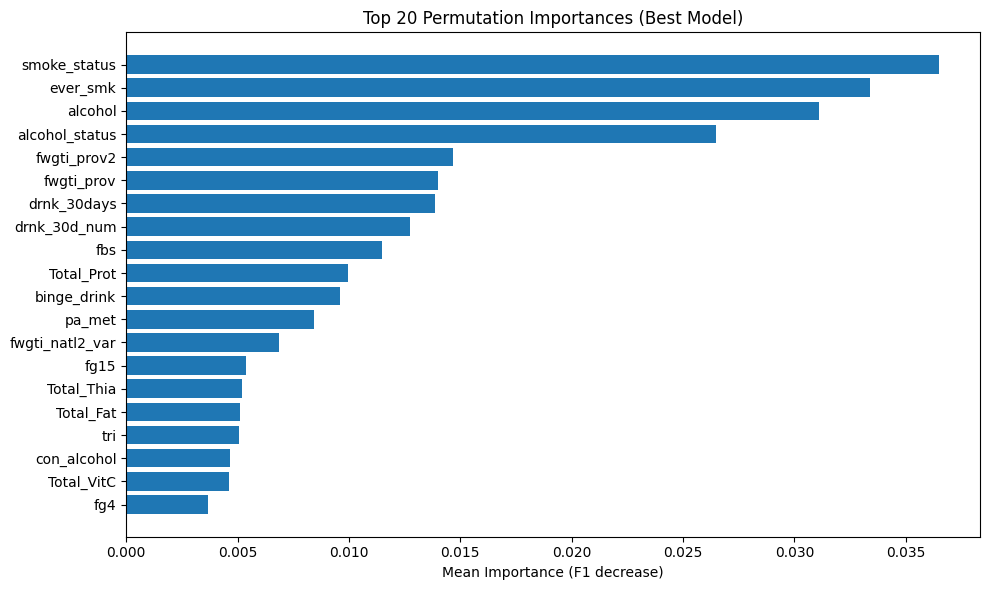


Top SHAP features:
        feature  mean_abs_shap
         pa_met       0.186562
        alcohol       0.173522
   smoke_status       0.132650
 alcohol_status       0.110237
           fg25       0.087188
            fbs       0.087110
      Total_Nia       0.051969
     fwgti_prov       0.049135
       ever_smk       0.039160
           chol       0.038409
 fwgti_natl_var       0.037232
    fwgti_prov2       0.037051
   drnk_30d_num       0.036958
    drnk_30days       0.036780
fwgti_natl2_var       0.036660
            hdl       0.035581
      Total_Fat       0.035493
            fg1       0.034676
            ldl       0.031178
           fg15       0.031102
Saved: c:\Jon\College\Thesis\V2.2.1.1\V2.2.1.1\clinical_dietary_multiyear_artifacts\explanation_shap_importance.csv


In [11]:
# Explanation layer
perm = permutation_importance(
    best_model,
    X_test_final,
    y_test,
    n_repeats=8,
    random_state=RANDOM_SEED,
    scoring="f1",
)

perm_df = pd.DataFrame({
    "feature": X_test_final.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

perm_path = ARTIFACT_DIR / "explanation_permutation_importance.csv"
perm_df.to_csv(perm_path, index=False)
print("Top permutation importance features:")
print(perm_df.head(20).to_string(index=False))
print(f"Saved: {perm_path}")

plt.figure(figsize=(10, 6))
top_plot = perm_df.head(20).iloc[::-1]
plt.barh(top_plot["feature"], top_plot["importance_mean"])
plt.title("Top 20 Permutation Importances (Best Model)")
plt.xlabel("Mean Importance (F1 decrease)")
plt.tight_layout()
plt.show()

# Optional SHAP for tree-based models only
tree_tokens = ["xgb", "lgb", "catboost", "forest", "tree", "boost"]
model_name_lc = type(best_model).__name__.lower()

if any(tok in model_name_lc for tok in tree_tokens):
    try:
        import shap

        sample_n = min(2000, len(X_train_final))
        X_bg = X_train_final.sample(sample_n, random_state=RANDOM_SEED)

        explainer = shap.TreeExplainer(best_model)
        shap_values = explainer.shap_values(X_bg)

        if isinstance(shap_values, list):
            sv = shap_values[1] if len(shap_values) > 1 else shap_values[0]
        else:
            sv = shap_values

        shap_importance = np.abs(sv).mean(axis=0)
        shap_df = pd.DataFrame({
            "feature": X_bg.columns,
            "mean_abs_shap": shap_importance,
        }).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

        shap_path = ARTIFACT_DIR / "explanation_shap_importance.csv"
        shap_df.to_csv(shap_path, index=False)

        print("\nTop SHAP features:")
        print(shap_df.head(20).to_string(index=False))
        print(f"Saved: {shap_path}")
    except Exception as e:
        print(f"SHAP skipped due to runtime issue: {e}")
else:
    print("SHAP skipped for non-tree model. Permutation importance already generated.")

In [12]:
print("Pipeline complete. Artifacts generated:")
for p in sorted(ARTIFACT_DIR.glob("*")):
    if p.is_file():
        print(f"- {p.name}")

print("\nModel files:")
for p in sorted(MODEL_DIR.glob("*.joblib")):
    print(f"- {p.name}")

Pipeline complete. Artifacts generated:
- best_calibrated_test_metrics.csv
- best_model_config.json
- calibration_results_clinical_dietary.csv
- explanation_permutation_importance.csv
- explanation_shap_importance.csv
- merged_clinical_dietary_multiyear.csv
- model_selection_results_clinical_dietary.csv
- preprocessing_bundle.joblib

Model files:
- LogReg.joblib
- RandomForest.joblib
- XGBoost.joblib
